# Proyecto Final Integrador — Café Cordillera

**TCNT0011 · Probabilidad y Estadística I · LEAD University**

Cuaderno de cálculo unificado. Contiene los diez sellos sobre un mismo dataset:
`cafe_cordillera_dataset.csv` (11,983 transacciones · 7,731 pedidos · 2,600 clientes · marzo–mayo 2026 · 4 sucursales).

| Sello | Técnica | Pregunta de negocio |
|---|---|---|
| 1 | Descriptiva y visualización | ¿Qué se vende, dónde y cuánto factura Café Cordillera? |
| 2 | Probabilidad condicional | ¿Comprar bebida caliente aumenta la probabilidad de comprar postre? |
| 3 | Teorema de Bayes | Si un cliente compró postre en su primera visita, ¿qué tan probable es que vuelva? |
| 4 | Distribuciones (Poisson) | ¿Cuántos clientes puede esperar una sucursal en una hora dada? |
| 5 | Muestreo y sesgos | ¿La calificación de satisfacción representa a todos los clientes? |
| 6 | Intervalos de confianza | ¿Cuál es el ticket promedio real y con qué margen de error? |
| 7 | Prueba de hipótesis | ¿Una sucursal vende de verdad más que otra, o es azar? |
| 8 | A/B Testing | ¿La promoción activa realmente aumenta las ventas? |
| 9 | Correlación vs. causalidad | ¿El clima *causa* que se venda más bebida caliente? |
| 10 | Regresión | ¿Qué variables predicen mejor las unidades vendidas? |

**Integrantes:**

- Luciana Carabaguiaz
- Diego Díaz
- Julián Maroto
- Santiago Volio

**Ejecución:** correr las celdas en orden. La celda 0 (Setup) carga el dataset una sola vez y define `df` y `monto` para todos los sellos.

## 0. Setup — carga única del dataset

Todas las librerías y la carga del CSV se hacen aquí una sola vez. Los sellos siguientes reutilizan el mismo `df`.

En Google Colab: subir `cafe_cordillera_dataset.csv` al panel de archivos (icono de carpeta a la izquierda) antes de ejecutar, o descomentar el bloque `files.upload()`.

In [1]:
# =============================================================
# SETUP GLOBAL - Librerias y carga del dataset
# =============================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

# --- Colab: descomentar para subir el archivo manualmente ---
# from google.colab import files; files.upload()

DATA_PATH = None
for _p in ["cafe_cordillera_dataset.csv",
           "../cafe_cordillera_dataset.csv",
           "/content/cafe_cordillera_dataset.csv",
           "/content/drive/MyDrive/cafe_cordillera_dataset.csv"]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontro cafe_cordillera_dataset.csv. "
        "Subalo al entorno o ajuste DATA_PATH manualmente."
    )

df = pd.read_csv(DATA_PATH, parse_dates=["fecha"])
df["monto"] = df["precio_unitario"] * df["unidades"]

print(f"Archivo: {DATA_PATH}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"Pedidos unicos: {df['id_pedido'].nunique():,} | Clientes: {df['id_cliente'].nunique():,}")
print(f"Rango de fechas: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Sucursales: {', '.join(sorted(df['sucursal'].unique()))}")
print()
print(df.head(3).to_string(index=False))

Archivo: cafe_cordillera_dataset.csv
Filas: 11,983 | Columnas: 16
Pedidos unicos: 7,731 | Clientes: 2,600
Rango de fechas: 2026-03-02 a 2026-05-31
Sucursales: Cartago, Escazu, Heredia, San Pedro

 id_transaccion  id_pedido  id_cliente      fecha  hora sucursal producto   categoria  precio_unitario  unidades  medio_pago    clima  promocion_activa promocion_tipo  calificacion_satisfaccion  monto
              1       2033         697 2026-03-02     6  Cartago Limonada bebida_fria             1284         1     tarjeta lluvioso                 0            NaN                        NaN   1284
              2       2033         697 2026-03-02     6  Cartago  Galleta      postre              841         1 sinpe_movil lluvioso                 0            NaN                        NaN    841
              3       2033         697 2026-03-02     6  Cartago   Frappe bebida_fria             1785         1 sinpe_movil lluvioso                 0            NaN                        NaN   1785


---

# Sello 1 — Descriptiva y visualización

### ¿Qué se vende, dónde y cuánto factura Café Cordillera?

**Pregunta de negocio del sello:** perfil de ventas — qué se vende, dónde y cuánto.

> Método: media, mediana y desviación estándar de `precio_unitario` y `unidades` por sucursal y por categoría, más gráficos de facturación por sucursal, por categoría y top 10 de productos.

In [2]:
df.head()

,id_transaccion,id_pedido,id_cliente,fecha,hora,sucursal,producto,categoria,precio_unitario,unidades,medio_pago,clima,promocion_activa,promocion_tipo,calificacion_satisfaccion,monto
0,1,2033,697,2026-03-02,6,Cartago,Limonada,bebida_fria,1284,1,tarjeta,lluvioso,0,NaN,NaN,1284
1,2,2033,697,2026-03-02,6,Cartago,Galleta,postre,841,1,sinpe_movil,lluvioso,0,NaN,NaN,841
2,3,2033,697,2026-03-02,6,Cartago,Frappe,bebida_fria,1785,1,sinpe_movil,lluvioso,0,NaN,NaN,1785
3,4,3564,1222,2026-03-02,6,Cartago,Limonada,bebida_fria,1189,3,tarjeta,lluvioso,0,NaN,4.0,3567
4,5,3564,1222,2026-03-02,6,Cartago,Cappuccino,bebida_caliente,1605,1,sinpe_movil,lluvioso,0,NaN,4.0,1605


El dataset contiene información de las transacciones realizadas por Café Cordillera. Para este análisis se utilizan las variables relacionadas con precio, unidades, producto, categoría y sucursal.

In [3]:
df["monto"] = df["precio_unitario"] * df["unidades"]

Se creó la variable monto, calculada multiplicando el precio unitario por la cantidad de unidades vendidas en cada transacción.

In [4]:
estadistica_sucursal = df.groupby("sucursal")[["precio_unitario", "unidades"]].agg(
    ["mean", "median", "std"]
)

estadistica_sucursal

precio_unitario                      unidades                 
                     mean  median         std      mean median       std
sucursal                                                                
Cartago       1513.714334  1505.0  328.861731  1.470727    1.0  0.747587
Escazu        1751.126995  1736.0  378.651651  1.385971    1.0  0.680110
Heredia       1538.127646  1527.0  326.774316  1.443452    1.0  0.730764
San Pedro     1582.982209  1559.0  337.766259  1.423296    1.0  0.705258

Se calcularon la media, mediana y desviación estándar del precio unitario y de las unidades vendidas para cada sucursal. Esto permite comparar el comportamiento de las ventas entre las diferentes ubicaciones.

In [5]:
estadistica_categoria = df.groupby("categoria")[["precio_unitario", "unidades"]].agg(
    ["mean", "median", "std"]
)

estadistica_categoria

precio_unitario                      unidades                 
                           mean  median         std      mean median       std
categoria                                                                     
bebida_caliente     1538.368773  1590.0  226.360173  1.457497    1.0  0.739404
bebida_fria         1536.539857  1418.0  279.450555  1.418178    1.0  0.702910
postre              1603.095266  1667.5  481.596620  1.405889    1.0  0.707989
snack               2324.603426  2350.0  252.116753  1.436100    1.0  0.712359

Se calcularon la media, mediana y desviación estándar del precio unitario y de las unidades vendidas para cada categoría. Esto permite identificar diferencias en el comportamiento de los productos según su categoría.

In [6]:
ventas_sucursal = df.groupby("sucursal")["monto"].sum().sort_values(ascending=False)

ventas_sucursal

,monto
sucursal,
Escazu,7295509
Heredia,6713070
San Pedro,6698328
Cartago,6616884


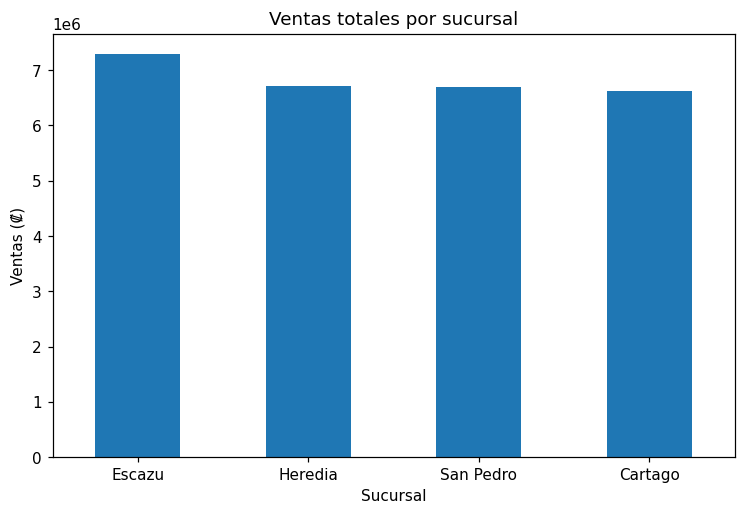

In [7]:
plt.figure(figsize=(8, 5))

ventas_sucursal.plot(kind="bar")

plt.title("Ventas totales por sucursal")
plt.xlabel("Sucursal")
plt.ylabel("Ventas (₡)")
plt.xticks(rotation=0)

plt.show()

El gráfico permite comparar la facturación total de las cuatro sucursales. La sucursal con mayor facturación es Escazú, por lo que representa la ubicación con mayor aporte a las ventas durante el periodo analizado.

In [8]:
ventas_categoria = df.groupby("categoria")["monto"].sum().sort_values(ascending=False)

ventas_categoria

,monto
categoria,
bebida_fria,11855048
bebida_caliente,9038946
postre,3903927
snack,2525870


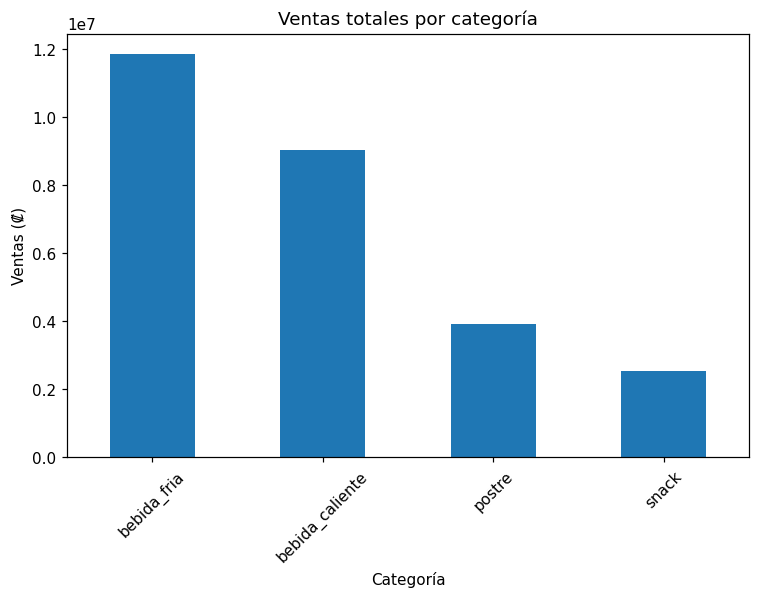

In [9]:
plt.figure(figsize=(8, 5))

ventas_categoria.plot(kind="bar")

plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas (₡)")
plt.xticks(rotation=45)

plt.show()

La categoría con mayor facturación es bebida fría, por lo que se identifica como la categoría estrella de Café Cordillera.

In [10]:
ventas_producto = df.groupby("producto")["monto"].sum().sort_values(ascending=False)

ventas_producto.head(10)

,monto
producto,
Frappe,4733463
Te helado,3662425
Limonada,3459160
Latte,2464378
Cappuccino,2382634
Chocolate caliente,2330256
Cafe americano,1861678
Sandwich,1373301
Cheesecake,1297895


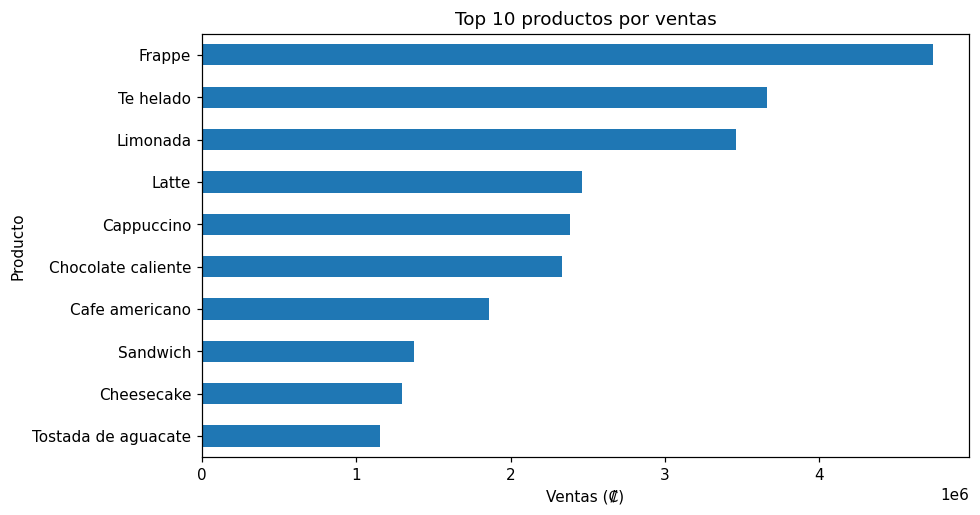

In [11]:
top10 = ventas_producto.head(10)

plt.figure(figsize=(9, 5))

top10.sort_values().plot(kind="barh")

plt.title("Top 10 productos por ventas")
plt.xlabel("Ventas (₡)")
plt.ylabel("Producto")

plt.show()

A partir de las ventas totales por producto, se identifica Frappe como el producto estrella, ya que presenta la mayor facturación durante el periodo analizado.

---

# Sello 2 — Probabilidad condicional

### ¿Quién pide postre si ya pidió bebida caliente?

**Pregunta de negocio del sello:** ¿comprar bebida caliente aumenta la probabilidad de comprar postre en el mismo pedido?

> Método: agregación por `id_pedido` para construir los eventos, tabla de contingencia, y comparación de P(postre) marginal contra P(postre | bebida caliente).

In [12]:
df["categoria"].unique()

array(['bebida_fria', 'postre', 'bebida_caliente', 'snack'], dtype=object)

In [13]:
categorias_por_pedido = df.groupby("id_pedido")["categoria"].agg(set)

categorias_por_pedido.head()

,categoria
id_pedido,
1,{bebida_caliente}
2,{bebida_caliente}
3,{bebida_caliente}
4,"{snack, bebida_fria, postre}"
5,{bebida_caliente}


In [14]:
tiene_postre = categorias_por_pedido.apply(
    lambda categorias: "postre" in categorias
)

tiene_postre.head()

,categoria
id_pedido,
1,False
2,False
3,False
4,True
5,False


In [15]:
tiene_bebida_caliente = categorias_por_pedido.apply(
    lambda categorias: "bebida_caliente" in categorias
)

tiene_bebida_caliente.head()

,categoria
id_pedido,
1,True
2,True
3,True
4,False
5,True


In [16]:
datos_sello2 = pd.DataFrame({
    "bebida_caliente": tiene_bebida_caliente,
    "postre": tiene_postre
})

datos_sello2.head()

,bebida_caliente,postre
id_pedido,,
1,True,False
2,True,False
3,True,False
4,False,True
5,True,False




- **A:** el pedido contiene una bebida caliente.
- **B:** el pedido contiene un postre.

Las variables se construyeron agrupando las transacciones por `id_pedido`, de manera que se pueda determinar si ambos productos fueron comprados dentro del mismo pedido.

In [17]:
tabla_contingencia = pd.crosstab(
    datos_sello2["bebida_caliente"],
    datos_sello2["postre"]
)

tabla_contingencia

postre,False,True
bebida_caliente,,
False,3181,889
True,2936,725


La tabla de contingencia permite observar la relación entre la compra de una bebida caliente y la compra de un postre dentro del mismo pedido.

Las filas representan si el pedido contiene una bebida caliente y las columnas representan si contiene un postre.

In [18]:
p_postre = datos_sello2["postre"].mean()

print(f"P(postre) = {p_postre:.4f}")
print(f"P(postre) = {p_postre:.2%}")

P(postre) = 0.2088
P(postre) = 20.88%


In [19]:
p_postre_dado_bebida = datos_sello2[
    datos_sello2["bebida_caliente"] == True
]["postre"].mean()

print(f"P(postre | bebida caliente) = {p_postre_dado_bebida:.4f}")
print(f"P(postre | bebida caliente) = {p_postre_dado_bebida:.2%}")

P(postre | bebida caliente) = 0.1980
P(postre | bebida caliente) = 19.80%


In [20]:
diferencia = p_postre_dado_bebida - p_postre

print(f"Diferencia = {diferencia:.4f}")
print(f"Diferencia = {diferencia:.2%}")

Diferencia = -0.0107
Diferencia = -1.07%


La probabilidad general de que un pedido incluya un postre es de 20.88%.
Cuando el pedido contiene una bebida caliente, esta probabilidad disminuye a 19.80%.

La diferencia es de -1.08 puntos porcentuales, por lo que comprar una bebida caliente no aumenta la probabilidad de comprar un postre.

##Conclusion

Los resultados muestran que comprar una bebida caliente no aumenta la probabilidad de comprar un postr. La probabilidad general de comprar un postre es de 20.88%, mientras que entre los pedidos con bebida caliente es de 19.80%. Por lo tanto, con estos datos no se observa evidencia de que un combo de bebida caliente + postre, por sí solo, tenga una ventaja en términos de aumentar la probabilidad de compra del postre.

---

# Sello 3 — Teorema de Bayes

### Actualiza la probabilidad de que un cliente vuelva

**Pregunta de negocio del sello:** si un cliente compró postre en su primera visita, ¿qué tan probable es que vuelva?

> Método: reconstrucción del orden cronológico de pedidos por cliente, definición explícita de los eventos A (recurrente) y B (primera compra con postre), y aplicación término a término de P(A|B) = P(B|A)·P(A) / P(B).

In [21]:
d = df.copy()

# Fecha y hora para ordenar cronológicamente los pedidos
d["datetime"] = pd.to_datetime(
    d["fecha"].astype(str) + " " + d["hora"].astype(str) + ":00:00"
)

# Un registro por pedido
pedidos = (
    d.groupby("id_pedido")
    .agg(
        id_cliente=("id_cliente", "first"),
        datetime=("datetime", "min")
    )
    .reset_index()
)

# Orden de los pedidos de cada cliente
pedidos = pedidos.sort_values(["id_cliente", "datetime", "id_pedido"])
pedidos["orden_cliente"] = pedidos.groupby("id_cliente").cumcount() + 1

# Cliente recurrente = realizó más de un pedido
cantidad_pedidos = pedidos.groupby("id_cliente").size()
pedidos["recurrente"] = pedidos["id_cliente"].map(cantidad_pedidos) > 1

# ¿El pedido contiene al menos un postre?
postre_por_pedido = (
    d.groupby("id_pedido")["categoria"]
    .apply(lambda x: x.eq("postre").any())
)
pedidos["tiene_postre"] = pedidos["id_pedido"].map(postre_por_pedido).fillna(False)

# Primera compra de cada cliente
primera_compra = pedidos[pedidos["orden_cliente"] == 1].copy()

print(f"Clientes analizados: {primera_compra['id_cliente'].nunique():,}")
print(f"Clientes recurrentes: {primera_compra['recurrente'].sum():,}")
print(f"Primeras compras con postre: {primera_compra['tiene_postre'].sum():,}")

Clientes analizados: 2,600
Clientes recurrentes: 1,121
Primeras compras con postre: 435




A: el cliente es recurrente, es decir, realizó más de un pedido durante el período analizado.

B: la primera compra del cliente incluyó al menos un producto de la categoría postre.

La probabilidad que queremos obtener es P(A|B): la probabilidad de que el cliente vuelva dado que compró postre en su primera visita.

In [22]:
tabla = pd.crosstab(
    primera_compra["tiene_postre"],
    primera_compra["recurrente"]
)

tabla.index = ["Sin postre", "Con postre"]
tabla.columns = ["No recurrente", "Recurrente"]

print(tabla)


            No recurrente  Recurrente
Sin postre           1304         861
Con postre            175         260




La tabla muestra simultáneamente si el cliente compró postre en su primera visita y si posteriormente volvió.

In [23]:
P_A = primera_compra["recurrente"].mean()
P_B = primera_compra["tiene_postre"].mean()

print(f"P(A) = {P_A:.4f} = {P_A*100:.2f}%")
print(f"P(B) = {P_B:.4f} = {P_B*100:.2f}%")

P(A) = 0.4312 = 43.12%
P(B) = 0.1673 = 16.73%




Primero calculamos la probabilidad general de que un cliente vuelva,

P(A) = clientes recurrentes / total de clientes

Y calculamos la probabilidad de que la primera compra haya incluido postre,

P(B) = primeras compras con postre / total de clientes

In [24]:
recurrentes = primera_compra[primera_compra["recurrente"]]
P_B_dado_A = recurrentes["tiene_postre"].mean()

print(f"P(B|A) = {P_B_dado_A:.4f} = {P_B_dado_A*100:.2f}%")

P(B|A) = 0.2319 = 23.19%


calculamos la probabilidad de que un cliente haya comprado postre en su primera visita sabiendo que fue recurrente:

P(B|A) = clientes recurrentes cuya primera compra tuvo postre / clientes recurrentes

In [25]:
P_A_dado_B = (P_B_dado_A * P_A) / P_B

print("Teorema de Bayes:")
print("P(A|B) = [P(B|A) × P(A)] / P(B)")
print(f"P(A|B) = [({P_B_dado_A:.4f}) × ({P_A:.4f})] / ({P_B:.4f})")
print(f"P(A|B) = {P_A_dado_B:.4f} = {P_A_dado_B*100:.2f}%")

Teorema de Bayes:
P(A|B) = [P(B|A) × P(A)] / P(B)
P(A|B) = [(0.2319) × (0.4312)] / (0.1673)
P(A|B) = 0.5977 = 59.77%


**Aplicación del Teorema de Bayes**

La fórmula usada es:
P(A|B) = [P(B|A) × P(A)] / P(B)`

Sustituimos cada término obtenido directamente del dataset para actualizar la probabilidad de recurrencia después de conocer la evidencia de que el cliente compró postre en su primera visita.

In [26]:
comparacion = pd.DataFrame({
    "Situación": [
        "Probabilidad general de volver",
        "Si compró postre en la primera visita"
    ],
    "Probabilidad": [P_A, P_A_dado_B]
})

comparacion["Porcentaje"] = comparacion["Probabilidad"] * 100
print(comparacion[["Situación", "Porcentaje"]].to_string(index=False))

incremento = P_A_dado_B - P_A
print(f"\nIncremento: {incremento*100:.2f} puntos porcentuales")

                            Situación  Porcentaje
       Probabilidad general de volver   43.115385
Si compró postre en la primera visita   59.770115

Incremento: 16.65 puntos porcentuales


Se compara la probabilidad general de recurrencia con la probabilidad actualizada cuando sabemos que la primera compra incluyó postre

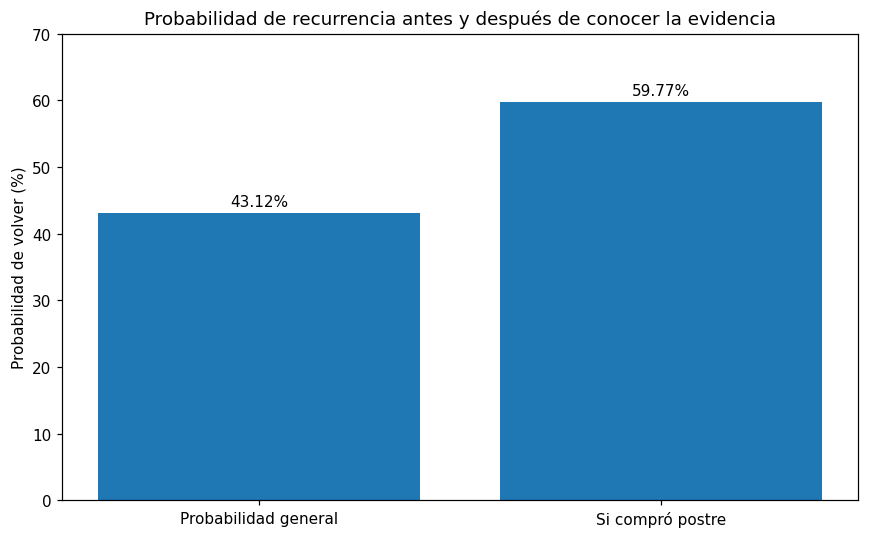

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(
    ["Probabilidad general", "Si compró postre"],
    [P_A * 100, P_A_dado_B * 100]
)
plt.ylabel("Probabilidad de volver (%)")
plt.title("Probabilidad de recurrencia antes y después de conocer la evidencia")
plt.ylim(0, 70)

for i, valor in enumerate([P_A * 100, P_A_dado_B * 100]):
    plt.text(i, valor + 1, f"{valor:.2f}%", ha="center")

plt.tight_layout()
plt.show()


La probabilidad general de que un cliente vuelva es de 43.12 %. Al conocer que su primera compra incluyó un postre la probabilidad de recurrencia aumenta a 59.77 %, una diferencia de 16.65 puntos porcentuales. Esto indica que la compra de postre está asociada con una mayor probabilidad de que el cliente sea recurrente. Esta información puede ser útil para identificar clientes con mayor potencial de fidelización y evaluar estrategias relacionadas con postres, pero este análisis no demuestra que comprar postre sea la causa de que el cliente vuelva

---

# Sello 4 — Distribuciones

### ¿Cuántos clientes puede esperar una sucursal en una hora dada?

**Pregunta de negocio del sello:** modelar la llegada de pedidos por hora para dimensionar personal e inventario.

> Método: conteo de pedidos por celda `sucursal × fecha × hora`, índice de dispersión (var/media) para elegir entre Poisson y Binomial, y prueba chi-cuadrado de bondad de ajuste en las 56 celdas.

Celdas (sucursal x fecha x hora): 5096
Pedidos en la malla: 7731 | pedidos únicos en el dataset: 7731

GLOBAL   media=1.517  varianza=1.978  indice=1.304
POR CELDA (sucursal x hora)  indice medio=0.989

Detalle San Pedro:
        lam  varianza   n  indice_dispersion
hora                                        
6     0.879     0.796  91              0.906
7     2.747     2.747  91              1.000
8     2.352     1.808  91              0.769
9     2.495     2.831  91              1.135
10    0.769     0.713  91              0.927
11    0.615     0.617  91              1.003
12    1.505     2.164  91              1.437
13    1.374     1.370  91              0.997
14    0.813     0.642  91              0.790
15    0.615     0.817  91              1.328
16    1.912     1.948  91              1.019
17    1.967     2.166  91              1.101
18    2.374     1.970  91              0.830
19    0.868     0.649  91              0.748

Bondad de ajuste en 56 celdas -> rechazan H0 al 5%: 8
(Co

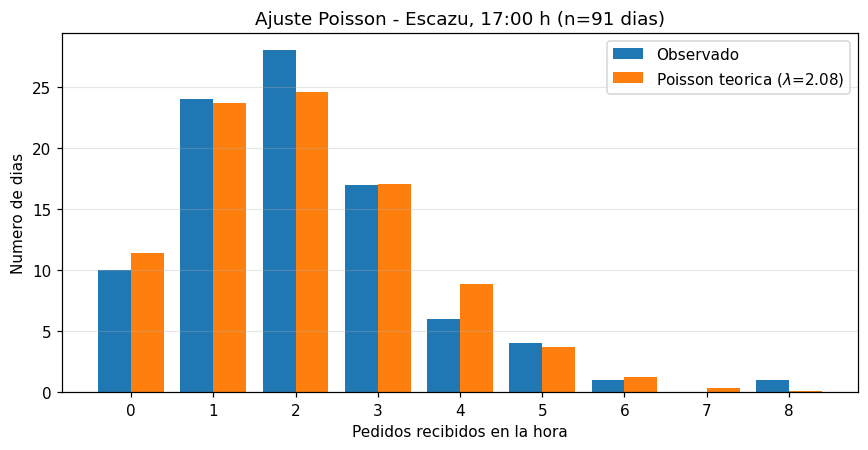

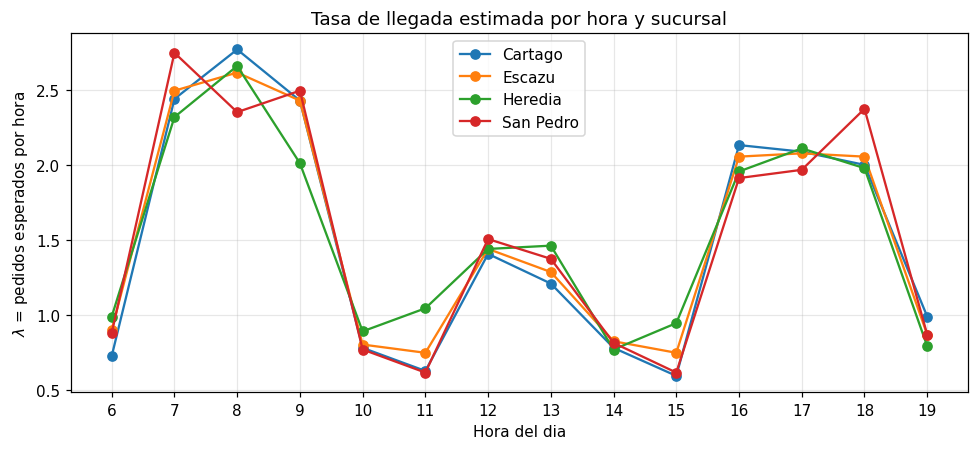


Lambda por hora y sucursal:
sucursal  Cartago  Escazu  Heredia  San Pedro
hora                                         
6            0.73    0.90     0.99       0.88
7            2.44    2.49     2.32       2.75
8            2.77    2.62     2.66       2.35
9            2.43    2.43     2.01       2.49
10           0.78    0.80     0.89       0.77
11           0.63    0.75     1.04       0.62
12           1.41    1.44     1.44       1.51
13           1.21    1.29     1.46       1.37
14           0.78    0.82     0.77       0.81
15           0.59    0.75     0.95       0.62
16           2.13    2.05     1.96       1.91
17           2.09    2.08     2.11       1.97
18           2.00    2.05     1.98       2.37
19           0.99    0.87     0.79       0.87

Pronostico Escazu 17:00 con lambda=2.08:
  P(0 pedidos) = 0.1253
  P(N <= 2)    = 0.6559
  P(N >= 5)    = 0.0599
  Percentil 95 = 5 pedidos


In [28]:
# =============================================================
# SELLO 4 - DISTRIBUCIONES (Poisson)
# =============================================================
# -------------------------------------------------------------
# 1. Unidad de análisis: PEDIDOS (no transacciones).
#    Un cliente que llega genera 1 id_pedido con varias líneas.
#    Se construye la malla completa sucursal x fecha x hora para
#    NO perder las horas con 0 pedidos (si no, se sesga lambda).
# -------------------------------------------------------------
pedidos = df.drop_duplicates("id_pedido")[["id_pedido", "fecha", "hora", "sucursal"]]

malla = pd.MultiIndex.from_product(
    [sorted(df["sucursal"].unique()),
     sorted(df["fecha"].unique()),
     sorted(df["hora"].unique())],
    names=["sucursal", "fecha", "hora"]
)
llegadas = (pedidos.groupby(["sucursal", "fecha", "hora"]).size()
            .reindex(malla, fill_value=0)
            .reset_index(name="pedidos"))

print("Celdas (sucursal x fecha x hora):", len(llegadas))
print("Pedidos en la malla:", llegadas["pedidos"].sum(),
      "| pedidos únicos en el dataset:", df["id_pedido"].nunique())

# -------------------------------------------------------------
# 2. ¿Poisson o Binomial? Criterio: índice de dispersión = var/media.
#    Poisson exige var ≈ media (índice ≈ 1).
# -------------------------------------------------------------
media_g = llegadas["pedidos"].mean()
var_g = llegadas["pedidos"].var(ddof=1)
print(f"\nGLOBAL   media={media_g:.3f}  varianza={var_g:.3f}  indice={var_g/media_g:.3f}")

disp = llegadas.groupby(["sucursal", "hora"])["pedidos"].agg(lam="mean", varianza="var", n="size")
disp["indice_dispersion"] = disp["varianza"] / disp["lam"]
print(f"POR CELDA (sucursal x hora)  indice medio={disp['indice_dispersion'].mean():.3f}")
print("\nDetalle San Pedro:")
print(disp.loc["San Pedro"].round(3))

# -------------------------------------------------------------
# 3. Prueba formal de bondad de ajuste (chi-cuadrado) contra Poisson.
#    Se agrupan clases hasta esperada >= 5. gl = k_bins - 1 - 1
#    (se resta 1 extra porque lambda se estimó de los datos).
# -------------------------------------------------------------
def gof_poisson(x, min_esp=5):
    x = np.asarray(x, dtype=int)
    n, lam, kmax = len(x), x.mean(), int(x.max())
    obs = np.bincount(x, minlength=kmax + 1).astype(float)
    esp = stats.poisson.pmf(np.arange(kmax + 1), lam) * n
    esp[-1] += (1 - stats.poisson.cdf(kmax, lam)) * n   # cola superior
    bins, o, e, k0 = [], 0.0, 0.0, 0
    for k in range(kmax + 1):
        o += obs[k]; e += esp[k]
        if e >= min_esp:
            bins.append([k0, k, o, e]); k0, o, e = k + 1, 0.0, 0.0
    if o > 0 or e > 0:
        if bins:
            bins[-1][1] = kmax; bins[-1][2] += o; bins[-1][3] += e
        else:
            bins.append([k0, kmax, o, e])
    b = pd.DataFrame(bins, columns=["k_min", "k_max", "obs", "esp"])
    chi2 = ((b["obs"] - b["esp"]) ** 2 / b["esp"]).sum()
    gl = len(b) - 2
    p = 1 - stats.chi2.cdf(chi2, gl) if gl > 0 else np.nan
    return lam, chi2, gl, p, b

res = []
for (s, h), g in llegadas.groupby(["sucursal", "hora"]):
    lam, chi2, gl, p, _ = gof_poisson(g["pedidos"].values)
    res.append({"sucursal": s, "hora": h, "lambda": lam, "chi2": chi2, "gl": gl, "p_value": p})
res = pd.DataFrame(res)

print(f"\nBondad de ajuste en {len(res)} celdas -> rechazan H0 al 5%: {(res['p_value']<0.05).sum()}")
print("(Con 56 pruebas al 5% se esperan ~3 rechazos solo por azar)")
print(res.sort_values("p_value").head(5).round(4).to_string(index=False))

# -------------------------------------------------------------
# 4. Celda foco para graficar el ajuste
# -------------------------------------------------------------
SUC, HORA = "Escazu", 17
foco = llegadas[(llegadas["sucursal"] == SUC) & (llegadas["hora"] == HORA)]["pedidos"].values
lam, chi2, gl, p, tabla = gof_poisson(foco)
print(f"\nCELDA FOCO {SUC} {HORA}:00 -> lambda={lam:.3f}  chi2={chi2:.3f}  gl={gl}  p={p:.4f}")
print(tabla.round(2).to_string(index=False))

k = np.arange(0, foco.max() + 1)
obs_frec = np.bincount(foco, minlength=len(k))
esp_frec = stats.poisson.pmf(k, lam) * len(foco)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(k - 0.2, obs_frec, width=0.4, label="Observado")
ax.bar(k + 0.2, esp_frec, width=0.4, label=f"Poisson teorica ($\\lambda$={lam:.2f})")
ax.set_xlabel("Pedidos recibidos en la hora")
ax.set_ylabel("Numero de dias")
ax.set_title(f"Ajuste Poisson - {SUC}, {HORA}:00 h (n={len(foco)} dias)")
ax.set_xticks(k); ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

# -------------------------------------------------------------
# 5. Perfil de demanda: lambda por hora y sucursal
# -------------------------------------------------------------
lam_hora = llegadas.groupby(["hora", "sucursal"])["pedidos"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4.2))
for s in lam_hora.columns:
    ax.plot(lam_hora.index, lam_hora[s], marker="o", label=s)
ax.set_xlabel("Hora del dia")
ax.set_ylabel("$\\lambda$ = pedidos esperados por hora")
ax.set_title("Tasa de llegada estimada por hora y sucursal")
ax.set_xticks(lam_hora.index); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nLambda por hora y sucursal:")
print(lam_hora.round(2))

# -------------------------------------------------------------
# 6. Uso operativo del modelo
# -------------------------------------------------------------
print(f"\nPronostico {SUC} {HORA}:00 con lambda={lam:.2f}:")
print(f"  P(0 pedidos) = {stats.poisson.pmf(0, lam):.4f}")
print(f"  P(N <= 2)    = {stats.poisson.cdf(2, lam):.4f}")
print(f"  P(N >= 5)    = {1 - stats.poisson.cdf(4, lam):.4f}")
print(f"  Percentil 95 = {stats.poisson.ppf(0.95, lam):.0f} pedidos")

---

# Sello 5 — Muestreo y sesgos

### ¿La encuesta la llenan solo los clientes contentos?

**Pregunta de negocio del sello:** ¿la calificación de satisfacción que tenemos representa a todos los clientes?

> Método: cuantificación de datos faltantes, chi-cuadrado de independencia entre responder y cada variable observable, t-test de Welch sobre el monto, y análisis de sensibilidad del sesgo de no respuesta.

Faltantes en calificacion_satisfaccion: 8534 de 11983 (71.22%)
Tasa de respuesta global: 28.78%
Muestra efectiva: n=3449

Perfil de respondientes vs no respondientes:
        variable  tasa_min  tasa_max  brecha_pp    chi2  gl  p_value
            hora    0.2451    0.3401     9.5025 19.4570  13   0.1096
        sucursal    0.2746    0.2954     2.0839  4.0177   3   0.2596
           clima    0.2781    0.2931     1.5032  2.2114   2   0.3310
promocion_activa    0.2851    0.2892     0.4119  0.1995   1   0.6551
       categoria    0.2833    0.2927     0.9384  1.1419   3   0.7670
      dia_semana    0.2769    0.2971     2.0170  2.4093   6   0.8785
      medio_pago    0.2873    0.2883     0.0948  0.0098   2   0.9951

Monto medio -> respondio: 2,269 | no respondio: 2,285
Welch t=-0.648, p=0.5170


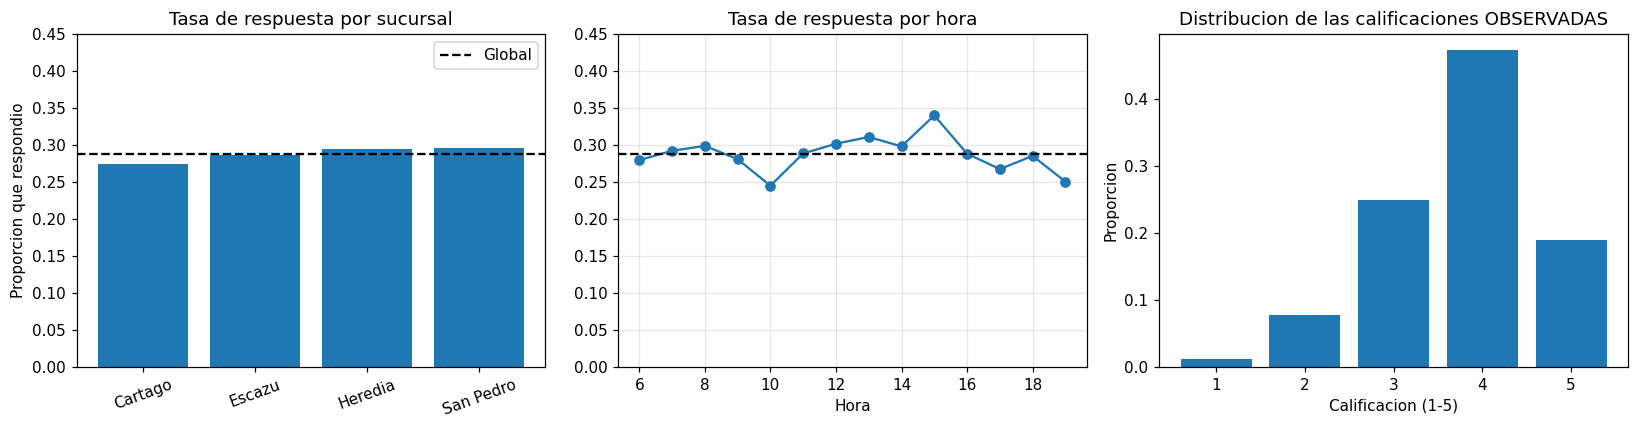


Distribucion observada de calificaciones:
calificacion_satisfaccion
1.0    0.0116
2.0    0.0768
3.0    0.2491
4.0    0.4726
5.0    0.1899
Name: proportion, dtype: float64

Media observada de satisfaccion = 3.752 (n=3449)
Escenarios si los no respondientes calificaran mas bajo:
 brecha_no_respondientes  media_real_estimada  sesgo_de_la_media_obs
                     0.0                3.752                  0.000
                    -0.5                3.396                  0.356
                    -1.0                3.040                  0.712
                    -1.5                2.684                  1.068


In [29]:
# =============================================================
# SELLO 5 - MUESTREO Y SESGOS
# =============================================================
df["respondio"] = df["calificacion_satisfaccion"].notna()
df["dia_semana"] = df["fecha"].dt.dayofweek

# -------------------------------------------------------------
# 1. Magnitud del problema
# -------------------------------------------------------------
n_tot = len(df)
n_falt = int(df["calificacion_satisfaccion"].isna().sum())
print(f"Faltantes en calificacion_satisfaccion: {n_falt} de {n_tot} ({n_falt/n_tot:.2%})")
print(f"Tasa de respuesta global: {df['respondio'].mean():.2%}")
print(f"Muestra efectiva: n={int(df['respondio'].sum())}\n")

# -------------------------------------------------------------
# 2. ¿Quién responde vs. quién no?
#    Chi-cuadrado de independencia entre cada variable observable
#    y el hecho de haber respondido. H0: responder es independiente
#    de esa variable (es decir, no hay sesgo detectable en ella).
# -------------------------------------------------------------
filas = []
for v in ["sucursal", "clima", "categoria", "promocion_activa",
          "medio_pago", "hora", "dia_semana"]:
    tabla = pd.crosstab(df[v], df["respondio"])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    tasa = df.groupby(v)["respondio"].mean()
    filas.append({"variable": v,
                  "tasa_min": tasa.min(), "tasa_max": tasa.max(),
                  "brecha_pp": (tasa.max() - tasa.min()) * 100,
                  "chi2": chi2, "gl": gl, "p_value": p})

comparacion = pd.DataFrame(filas).sort_values("p_value")
print("Perfil de respondientes vs no respondientes:")
print(comparacion.round(4).to_string(index=False))

# Variable continua: ¿gastan distinto los que responden?
a = df.loc[df["respondio"], "monto"]
b = df.loc[~df["respondio"], "monto"]
t_st, p_m = stats.ttest_ind(a, b, equal_var=False)
print(f"\nMonto medio -> respondio: {a.mean():,.0f} | no respondio: {b.mean():,.0f}")
print(f"Welch t={t_st:.3f}, p={p_m:.4f}")

# -------------------------------------------------------------
# 3. Gráficos
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tasa_suc = df.groupby("sucursal")["respondio"].mean()
axes[0].bar(tasa_suc.index, tasa_suc.values)
axes[0].axhline(df["respondio"].mean(), ls="--", color="black", label="Global")
axes[0].set_title("Tasa de respuesta por sucursal")
axes[0].set_ylabel("Proporcion que respondio"); axes[0].set_ylim(0, 0.45)
axes[0].legend(); axes[0].tick_params(axis="x", rotation=20)

tasa_hora = df.groupby("hora")["respondio"].mean()
axes[1].plot(tasa_hora.index, tasa_hora.values, marker="o")
axes[1].axhline(df["respondio"].mean(), ls="--", color="black")
axes[1].set_title("Tasa de respuesta por hora")
axes[1].set_xlabel("Hora"); axes[1].set_ylim(0, 0.45); axes[1].grid(alpha=.3)

dist = df["calificacion_satisfaccion"].value_counts(normalize=True).sort_index()
axes[2].bar(dist.index.astype(int), dist.values)
axes[2].set_title("Distribucion de las calificaciones OBSERVADAS")
axes[2].set_xlabel("Calificacion (1-5)"); axes[2].set_ylabel("Proporcion")

plt.tight_layout(); plt.show()

print("\nDistribucion observada de calificaciones:")
print(dist.round(4))

# -------------------------------------------------------------
# 4. Análisis de sensibilidad: cuánto se equivoca la gerencia si
#    asume que los no respondientes son iguales a los respondientes.
#    media_real = r * media_obs + (1-r) * (media_obs + brecha)
# -------------------------------------------------------------
m_obs = df["calificacion_satisfaccion"].mean()
r = df["respondio"].mean()

esc = pd.DataFrame({"brecha_no_respondientes": [0.0, -0.5, -1.0, -1.5]})
esc["media_real_estimada"] = r * m_obs + (1 - r) * (m_obs + esc["brecha_no_respondientes"])
esc["sesgo_de_la_media_obs"] = m_obs - esc["media_real_estimada"]

print(f"\nMedia observada de satisfaccion = {m_obs:.3f} (n={int(df['respondio'].sum())})")
print("Escenarios si los no respondientes calificaran mas bajo:")
print(esc.round(3).to_string(index=False))

---

# Sello 6 — Intervalos de confianza

### ¿Cuál es el ticket promedio real de Café Cordillera, con qué margen de error?

**Pregunta de negocio del sello:** estimar el ticket promedio con un rango, no con un punto.

> Método: IC del 95 % por t de Student sobre el ticket agregado por `id_pedido`, verificación por bootstrap (5,000 remuestreos) y desagregación por sucursal con forest plot.

count     7731.0
mean      3534.3
std       2302.5
min       1062.0
25%       1649.0
50%       3029.0
75%       4638.0
max      18409.0
Name: ticket, dtype: float64
Asimetria (skew) = 1.468

IC 95% GLOBAL del ticket
  media  = 3,534.3 CRC
  IC 95% = [3,483.0 ; 3,585.6]
  margen = +/- 51.3 CRC  (1.45% de la media)

IC 95% bootstrap (5,000 remuestreos): [3,481.7 ; 3,585.2]
Coincidencia con el IC t -> el uso del TCL es apropiado.

IC 95% del ticket por sucursal:
 sucursal    n  media  desv_est   ee  lim_inf  lim_sup  margen
  Cartago 1908 3468.0    2261.4 51.8   3366.4   3569.5   101.5
   Escazu 1942 3756.7    2410.8 54.7   3649.4   3864.0   107.3
  Heredia 1944 3453.2    2272.9 51.6   3352.1   3554.3   101.1
San Pedro 1937 3458.1    2248.0 51.1   3357.9   3558.3   100.2

IC 95% del monto por linea: 2,280.2 [2,257.6 ; 2,302.8]  (n=11983)


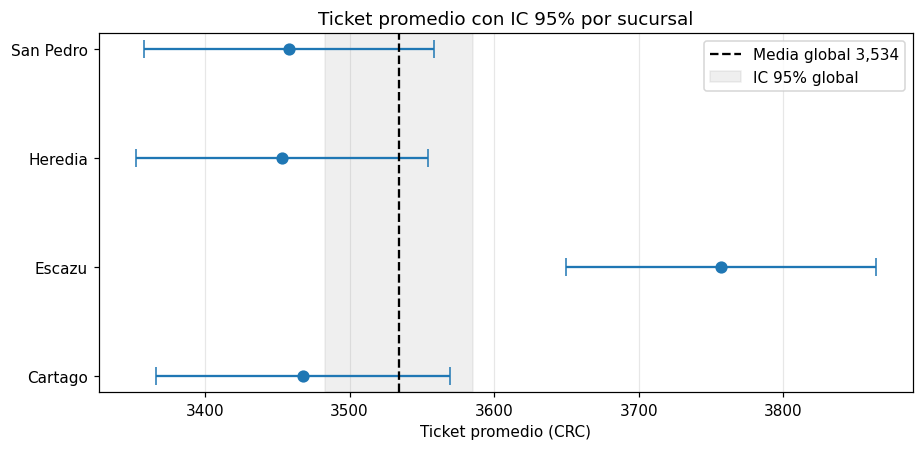


Traslape de intervalos entre sucursales:
  Cartago    vs Escazu     -> NO se traslapan
  Cartago    vs Heredia    -> se traslapan
  Cartago    vs San Pedro  -> se traslapan
  Escazu     vs Heredia    -> NO se traslapan
  Escazu     vs San Pedro  -> NO se traslapan
  Heredia    vs San Pedro  -> se traslapan


In [30]:
# =============================================================
# SELLO 6 - INTERVALOS DE CONFIANZA
# =============================================================
# Definición: ticket = gasto total de UN pedido = suma de
# (precio_unitario * unidades) de todas sus líneas.
# -------------------------------------------------------------
ticket = df.groupby("id_pedido")["monto"].sum().rename("ticket")
suc_pedido = df.drop_duplicates("id_pedido").set_index("id_pedido")["sucursal"]
tk = pd.concat([ticket, suc_pedido], axis=1)

print(tk["ticket"].describe().round(1))
print(f"Asimetria (skew) = {stats.skew(tk['ticket']):.3f}")

# -------------------------------------------------------------
# 1. IC de la media por t de Student.
#    Justificación: sigma poblacional desconocida -> t, no z.
#    La distribución del ticket es asimétrica a la derecha, pero
#    n = 7,731 hace que el TCL garantice normalidad de la MEDIA
#    muestral. Con gl > 5000, t practicamente coincide con z.
# -------------------------------------------------------------
def ic_media(x, conf=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    ee = x.std(ddof=1) / np.sqrt(n)          # error estandar
    t = stats.t.ppf(1 - (1 - conf) / 2, n - 1)
    return {"n": n, "media": m, "desv_est": x.std(ddof=1), "ee": ee,
            "lim_inf": m - t * ee, "lim_sup": m + t * ee, "margen": t * ee}

g = ic_media(tk["ticket"])
print(f"\nIC 95% GLOBAL del ticket")
print(f"  media  = {g['media']:,.1f} CRC")
print(f"  IC 95% = [{g['lim_inf']:,.1f} ; {g['lim_sup']:,.1f}]")
print(f"  margen = +/- {g['margen']:,.1f} CRC  ({g['margen']/g['media']:.2%} de la media)")

# -------------------------------------------------------------
# 2. Verificación con bootstrap (no asume normalidad).
#    Si coincide con el IC t, el supuesto del TCL se sostiene.
# -------------------------------------------------------------
rng = np.random.default_rng(42)
boot = rng.choice(tk["ticket"].values, size=(5000, len(tk)), replace=True).mean(axis=1)
lo_b, hi_b = np.percentile(boot, [2.5, 97.5])
print(f"\nIC 95% bootstrap (5,000 remuestreos): [{lo_b:,.1f} ; {hi_b:,.1f}]")
print("Coincidencia con el IC t -> el uso del TCL es apropiado.")

# -------------------------------------------------------------
# 3. IC por sucursal
# -------------------------------------------------------------
por_suc = pd.DataFrame([{"sucursal": s, **ic_media(gg["ticket"])}
                        for s, gg in tk.groupby("sucursal")])
print("\nIC 95% del ticket por sucursal:")
print(por_suc.round(1).to_string(index=False))

# IC del monto por linea de transaccion (metrica secundaria)
lin = ic_media(df["monto"])
print(f"\nIC 95% del monto por linea: {lin['media']:,.1f} "
      f"[{lin['lim_inf']:,.1f} ; {lin['lim_sup']:,.1f}]  (n={lin['n']})")

# -------------------------------------------------------------
# 4. Gráfico tipo forest plot
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.errorbar(por_suc["media"], por_suc["sucursal"],
            xerr=por_suc["margen"], fmt="o", capsize=6, markersize=7)
ax.axvline(g["media"], ls="--", color="black", label=f"Media global {g['media']:,.0f}")
ax.axvspan(g["lim_inf"], g["lim_sup"], alpha=.12, color="gray", label="IC 95% global")
ax.set_xlabel("Ticket promedio (CRC)")
ax.set_title("Ticket promedio con IC 95% por sucursal")
ax.legend(); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

# -------------------------------------------------------------
# 5. ¿Se traslapan los intervalos? (lectura preliminar; la prueba
#     formal corresponde al Sello 7)
# -------------------------------------------------------------
print("\nTraslape de intervalos entre sucursales:")
for i in range(len(por_suc)):
    for j in range(i + 1, len(por_suc)):
        a_, b_ = por_suc.iloc[i], por_suc.iloc[j]
        solapa = not (a_["lim_sup"] < b_["lim_inf"] or b_["lim_sup"] < a_["lim_inf"])
        print(f"  {a_['sucursal']:<10} vs {b_['sucursal']:<10} -> "
              f"{'se traslapan' if solapa else 'NO se traslapan'}")

---

# Sello 7 — Prueba de hipótesis

### ¿Una sucursal vende de verdad más que otra, o es azar?

**Pregunta de negocio del sello:** ¿existe una diferencia real en el monto promedio por transacción entre las cuatro sucursales, o las diferencias observadas se deben al azar?

**Modelo:** `monto ~ sucursal` (ANOVA de una vía + OLS con dummies + t-test de confirmación)

## 7.2 Planteamiento de hipótesis

Usamos **ANOVA de una vía** porque hay cuatro grupos independientes (cuatro sucursales) y queremos comparar sus medias simultáneamente. Hacer múltiples t-tests inflaría el error de Tipo I (problema de comparaciones múltiples).

- **H₀:** Las cuatro sucursales tienen el mismo monto promedio por transacción.  
  μ_Cartago = μ_Escazú = μ_Heredia = μ_San Pedro
- **H₁:** Al menos una sucursal tiene un monto promedio diferente.
- **Nivel de significancia:** α = 0.05

## 7.3 Estadísticos descriptivos por sucursal

In [31]:
resumen = df.groupby("sucursal")["monto"].agg(
    n="count", media="mean", std="std", mediana="median"
).round(2)
print("Estadísticos del monto (₡) por sucursal:")
print(resumen.to_string())

Estadísticos del monto (₡) por sucursal:
              n    media      std  mediana
sucursal                                  
Cartago    2972  2226.41  1251.01   1733.0
Escazu     3008  2425.37  1314.27   1911.5
Heredia    3024  2219.93  1241.46   1736.5
San Pedro  2979  2248.52  1223.94   1780.0


## 7.4 ANOVA de una vía

In [32]:
grupos = [g["monto"].values for _, g in df.groupby("sucursal")]
f_stat, p_valor = stats.f_oneway(*grupos)
print(f"Estadístico F : {f_stat:.4f}")
print(f"p-value       : {p_valor:.4e}")
print(f"α             : 0.05")
print()
if p_valor < 0.05:
    print("✅ DECISIÓN: Se rechaza H₀.")
    print("   Existe evidencia estadística de que al menos una sucursal"
          " tiene un monto promedio diferente (p < 0.05).")
else:
    print("❌ DECISIÓN: No se rechaza H₀.")

Estadístico F : 18.1006
p-value       : 1.0264e-11
α             : 0.05

✅ DECISIÓN: Se rechaza H₀.
   Existe evidencia estadística de que al menos una sucursal tiene un monto promedio diferente (p < 0.05).


## 7.5 Modelo OLS con dummies de sucursal

Ajustamos una regresión OLS con variables indicadoras para cuantificar la diferencia de cada sucursal respecto a la categoría de referencia (Cartago). Esto permite obtener coeficientes, errores estándar e intervalos de confianza por sucursal.

In [33]:
import statsmodels.api as sm

d = pd.get_dummies(df, columns=["sucursal"], drop_first=True, dtype=int)
suc_cols = [c for c in d.columns if c.startswith("sucursal_")]
X = sm.add_constant(d[suc_cols].astype(float))
modelo = sm.OLS(d["monto"].astype(float), X).fit()
print(modelo.summary().tables[1].as_text())
print(f"R² = {modelo.rsquared:.4f}  ·  R² ajustado = {modelo.rsquared_adj:.4f}")

                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2226.4078     23.080     96.466      0.000    2181.168    2271.648
sucursal_Escazu      198.9609     32.542      6.114      0.000     135.174     262.748
sucursal_Heredia      -6.4773     32.499     -0.199      0.842     -70.180      57.226
sucursal_San Pedro    22.1078     32.620      0.678      0.498     -41.833      86.049
R² = 0.0045  ·  R² ajustado = 0.0043


## 7.6 t-test de confirmación: Escazú vs Heredia (los extremos)

In [34]:
g_escazu  = df[df["sucursal"] == "Escazu"]["monto"]
g_heredia = df[df["sucursal"] == "Heredia"]["monto"]
t_stat, p_t = stats.ttest_ind(g_escazu, g_heredia)
print(f"Media Escazú  : ₡{g_escazu.mean():,.2f}")
print(f"Media Heredia : ₡{g_heredia.mean():,.2f}")
print(f"Diferencia    : ₡{g_escazu.mean() - g_heredia.mean():,.2f}")
print(f"t-estadístico : {t_stat:.4f}")
print(f"p-value       : {p_t:.4e}")
print(f"\nEscazú supera a Heredia en un {((g_escazu.mean()/g_heredia.mean())-1)*100:.1f}% en monto promedio.")

Media Escazú  : ₡2,425.37
Media Heredia : ₡2,219.93
Diferencia    : ₡205.44
t-estadístico : 6.2410
p-value       : 4.6443e-10

Escazú supera a Heredia en un 9.3% en monto promedio.


## 7.7 Visualización

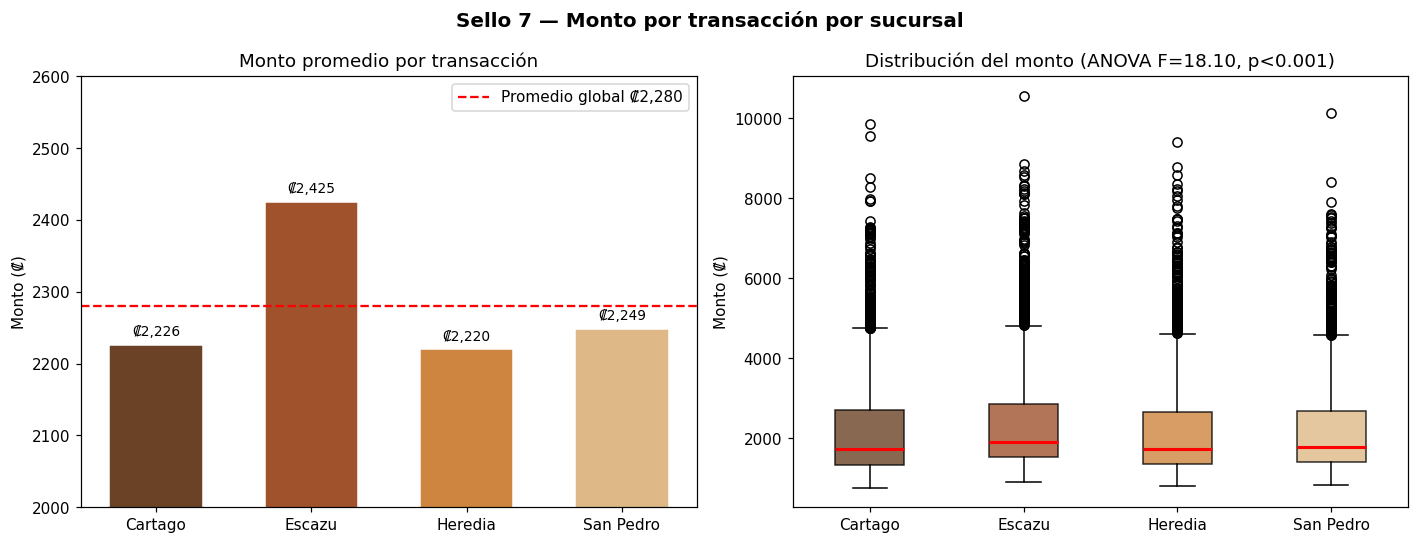

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sello 7 — Monto por transacción por sucursal", fontsize=13, fontweight="bold")

colores = ["#6B4226", "#A0522D", "#CD853F", "#DEB887"]
medias  = resumen["media"]

bars = axes[0].bar(medias.index, medias.values, color=colores, edgecolor="white", width=0.6)
axes[0].axhline(medias.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Promedio global ₡{medias.mean():,.0f}")
axes[0].set_title("Monto promedio por transacción")
axes[0].set_ylabel("Monto (₡)")
axes[0].set_ylim(2000, 2600)
axes[0].legend()
for bar, val in zip(bars, medias.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f"₡{val:,.0f}", ha="center", va="bottom", fontsize=9)

data_box = [df[df["sucursal"]==s]["monto"].values for s in medias.index]
bp = axes[1].boxplot(data_box, patch_artist=True,
                     medianprops=dict(color="red", linewidth=2))
axes[1].set_xticks(range(1, len(medias.index) + 1))
axes[1].set_xticklabels(medias.index)
for patch, color in zip(bp["boxes"], colores):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_title(f"Distribución del monto (ANOVA F={f_stat:.2f}, p<0.001)")
axes[1].set_ylabel("Monto (₡)")

plt.tight_layout()
plt.show()

## 7.8 Conclusión (lenguaje de negocio)

El ANOVA confirma con F = 18.10 y p < 0.001 que las diferencias entre sucursales no son producto del azar. **Escazú lidera** con un monto promedio de ₡2,425 por transacción, mientras que Heredia es la más baja con ₡2,220 — una brecha de ₡205 (9.3 %) que el t-test de confirmación valida con t = 6.24 y p < 0.001. El R² bajo (≈ 0.004) indica que la sucursal explica solo una fracción de la variabilidad total del monto, por lo que existen otros factores relevantes (categoría, promoción, hora). **Recomendación:** la gerencia debería identificar qué prácticas de Escazú — mix de productos, zona demográfica, atención — se pueden replicar en Heredia para reducir la brecha.

---

# Sello 8 — A/B Testing

### Promoción nueva contra la actual: ¿cuál gana?

**Pregunta de negocio del sello:** ¿existe un efecto real y significativo de las promociones sobre las unidades vendidas por transacción, o la diferencia podría explicarse por el azar?

**Modelo:** `unidades ~ promocion_activa` (t-test de Welch + OLS + validación sklearn)

## 8.2 Diseño del experimento y planteamiento de hipótesis

Tratamos `promocion_activa` como variable de asignación al grupo. Aunque no es un experimento controlado aleatorio puro (las promociones se asignaron según criterio de la cadena), el tamaño de muestra grande permite aplicar el marco de inferencia estadística.

- **H₀:** La promoción no cambia las unidades vendidas promedio. μ_A = μ_B
- **H₁:** La promoción *aumenta* las unidades vendidas. μ_B > μ_A
- **Prueba:** t-test de Welch (no asume igualdad de varianzas, apropiado cuando los grupos tienen tamaños distintos).
- **Nivel de significancia:** α = 0.05 · prueba unilateral (mayor que).

In [36]:
A = df[df["promocion_activa"] == 0]["unidades"]   # control
B = df[df["promocion_activa"] == 1]["unidades"]   # tratamiento
print(f"Grupo A (sin promo) : n={len(A):,}  |  media={A.mean():.4f}  |  std={A.std():.4f}")
print(f"Grupo B (con promo) : n={len(B):,}  |  media={B.mean():.4f}  |  std={B.std():.4f}")
print(f"\nDistribución de unidades:")
print(df.groupby("promocion_activa")["unidades"].value_counts().unstack(fill_value=0).to_string())

Grupo A (sin promo) : n=8,033  |  media=1.2667  |  std=0.6110
Grupo B (con promo) : n=3,950  |  media=1.7646  |  std=0.7961

Distribución de unidades:
unidades             1     2    3    4
promocion_activa                      
0                 6605   714  714    0
1                 1650  1756  368  176


## 8.3 t-test de Welch y tamaño del efecto

In [37]:
t_stat, p_valor = stats.ttest_ind(B, A, equal_var=False, alternative="greater")
pooled_std = np.sqrt((B.std()**2 + A.std()**2) / 2)
cohens_d   = (B.mean() - A.mean()) / pooled_std
lift       = (B.mean() / A.mean() - 1) * 100

print(f"t-estadístico : {t_stat:.4f}")
print(f"p-value       : {p_valor:.4e}")
print(f"Cohen's d     : {cohens_d:.4f}  → efecto {'grande' if abs(cohens_d)>=0.8 else 'mediano' if abs(cohens_d)>=0.5 else 'pequeño'}")
print(f"Lift          : +{lift:.1f}% más unidades con promoción")
print()
if p_valor < 0.05:
    print("✅ DECISIÓN: Se rechaza H₀.")
    print("   La promoción genera un aumento real y estadísticamente significativo")
    print("   en las unidades vendidas por transacción (p < 0.05).")
else:
    print("❌ DECISIÓN: No se rechaza H₀.")

t-estadístico : 34.6116
p-value       : 8.4500e-241
Cohen's d     : 0.7016  → efecto mediano
Lift          : +39.3% más unidades con promoción

✅ DECISIÓN: Se rechaza H₀.
   La promoción genera un aumento real y estadísticamente significativo
   en las unidades vendidas por transacción (p < 0.05).


## 8.4 Modelo OLS para cuantificar el efecto

Ajustamos una regresión OLS con `promocion_activa` como único predictor. El coeficiente β₁ cuantifica el efecto promedio de la promoción sobre las unidades, con su intervalo de confianza al 95 %.

In [38]:
import statsmodels.api as sm

X = sm.add_constant(df["promocion_activa"].astype(float))
modelo = sm.OLS(df["unidades"].astype(float), X).fit()
print(modelo.summary().tables[1].as_text())
print(f"R² = {modelo.rsquared:.4f}  ·  R² ajustado = {modelo.rsquared_adj:.4f}")

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.2667      0.008    167.528      0.000       1.252       1.281
promocion_activa     0.4979      0.013     37.809      0.000       0.472       0.524
R² = 0.1066  ·  R² ajustado = 0.1065


## 8.5 ¿Cuál tipo de promoción funciona mejor?

In [39]:
tipos = (
    df[df["promocion_activa"] == 1]
    .groupby("promocion_tipo")["unidades"]
    .agg(media="mean", n="count")
    .sort_values("media", ascending=False)
    .round(3)
)
print("Unidades promedio por tipo de promoción:")
print(tipos.to_string())
print(f"\nBaseline sin promoción : {A.mean():.3f} unidades")
print(f"Mejor tipo de promoción: {tipos.index[0]}")

Unidades promedio por tipo de promoción:
                media     n
promocion_tipo             
2x1_bebidas     1.779  1264
combo_postre    1.765  1194
descuento_10    1.751  1492

Baseline sin promoción : 1.267 unidades
Mejor tipo de promoción: 2x1_bebidas


## 8.6 Validación en datos no vistos (sklearn)

Separamos 75 % entrenamiento / 25 % prueba para medir el poder predictivo real del efecto de la promoción.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_ = df[["promocion_activa"]].to_numpy()
y_ = df["unidades"].to_numpy()
Xt, Xv, yt, yv = train_test_split(X_, y_, test_size=0.25, random_state=42)
lr = LinearRegression().fit(Xt, yt)
print(f"R² entrenamiento = {r2_score(yt, lr.predict(Xt)):.4f}")
print(f"R² validación    = {r2_score(yv, lr.predict(Xv)):.4f}")

R² entrenamiento = 0.1084
R² validación    = 0.1012


## 8.7 Visualización

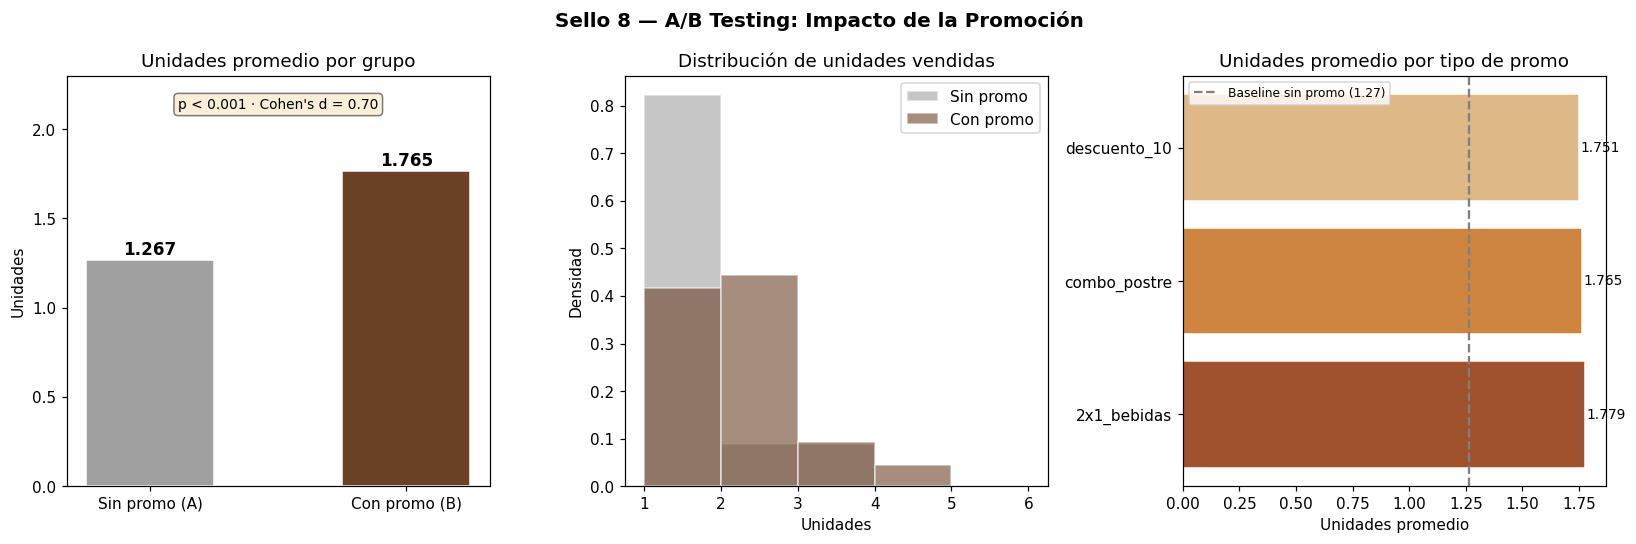

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Sello 8 — A/B Testing: Impacto de la Promoción", fontsize=13, fontweight="bold")

# 1. Barras A vs B
labels = ["Sin promo (A)", "Con promo (B)"]
medias_ab = [A.mean(), B.mean()]
bars = axes[0].bar(labels, medias_ab, color=["#A0A0A0", "#6B4226"], width=0.5, edgecolor="white")
axes[0].set_title("Unidades promedio por grupo")
axes[0].set_ylabel("Unidades")
axes[0].set_ylim(0, 2.3)
for bar, val in zip(bars, medias_ab):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[0].text(0.5, 0.92, f"p < 0.001 · Cohen's d = {cohens_d:.2f}",
             ha="center", transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# 2. Histograma de distribución
for data, label, color in [(A, "Sin promo", "#A0A0A0"), (B, "Con promo", "#6B4226")]:
    axes[1].hist(data, bins=range(1, 7), density=True, alpha=0.6,
                 color=color, label=label, edgecolor="white")
axes[1].set_title("Distribución de unidades vendidas")
axes[1].set_xlabel("Unidades")
axes[1].set_ylabel("Densidad")
axes[1].legend()

# 3. Por tipo de promoción
colores_tipos = ["#A0522D", "#CD853F", "#DEB887"]
axes[2].barh(tipos.index, tipos["media"], color=colores_tipos, edgecolor="white")
axes[2].axvline(A.mean(), color="gray", linestyle="--", linewidth=1.5,
                label=f"Baseline sin promo ({A.mean():.2f})")
axes[2].set_title("Unidades promedio por tipo de promo")
axes[2].set_xlabel("Unidades promedio")
axes[2].legend(fontsize=8)
for i, val in enumerate(tipos["media"]):
    axes[2].text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8.8 Conclusión (lenguaje de negocio)

Con t = 34.61 y p < 0.001, la evidencia es contundente: **las promociones sí aumentan las unidades vendidas**, no es azar. El modelo OLS cuantifica el efecto en **+0.50 unidades por transacción** cuando hay promoción activa (IC 95 %: [0.472, 0.524]), y el Cohen's d = 0.70 indica un efecto de magnitud **mediana-grande** — relevante en la práctica, no solo estadísticamente. El R² (≈ 0.11) se mantiene estable en validación (0.101), confirmando que el efecto es genuino y no sobreajuste. Entre los tres tipos de promoción, **2x1 en bebidas** genera el mayor volumen unitario promedio (1.779 unidades). **Recomendación:** mantener e invertir en las promociones, priorizando el 2x1 en bebidas como palanca principal de volumen.

---

# Sello 9 — Correlación vs. causalidad

### ¿El clima o la música "causan" más ventas?

**Pregunta de negocio del sello:** ¿el clima *causa* que se venda más bebida caliente?

> Método: tabla de contingencia, chi-cuadrado de independencia, Cramér's V y análisis de variables confusoras.

In [42]:
print("Clima:")
print(df["clima"].value_counts().to_string())
print("\nCategoría:")
print(df["categoria"].value_counts().to_string())

Clima:
clima
soleado     4575
nublado     4132
lluvioso    3276

Categoría:
categoria
bebida_fria        5457
bebida_caliente    4035
postre             1732
snack               759


## 9.2 ¿Existe relación entre clima y categoría?

Construimos la **tabla de contingencia**: cuántas transacciones de cada categoría ocurren bajo cada clima, en conteos y en proporción.

In [43]:
tabla = pd.crosstab(df["clima"], df["categoria"])
print("Conteos:\n", tabla.to_string())
print("\nProporción por clima (suma por fila = 1):")
print(tabla.div(tabla.sum(axis=1), axis=0).round(3).to_string())

Conteos:
 categoria  bebida_caliente  bebida_fria  postre  snack
clima                                                 
lluvioso              1374         1188     509    205
nublado               1295         1995     572    270
soleado               1366         2274     651    284

Proporción por clima (suma por fila = 1):
categoria  bebida_caliente  bebida_fria  postre  snack
clima                                                 
lluvioso             0.419        0.363   0.155  0.063
nublado              0.313        0.483   0.138  0.065
soleado              0.299        0.497   0.142  0.062


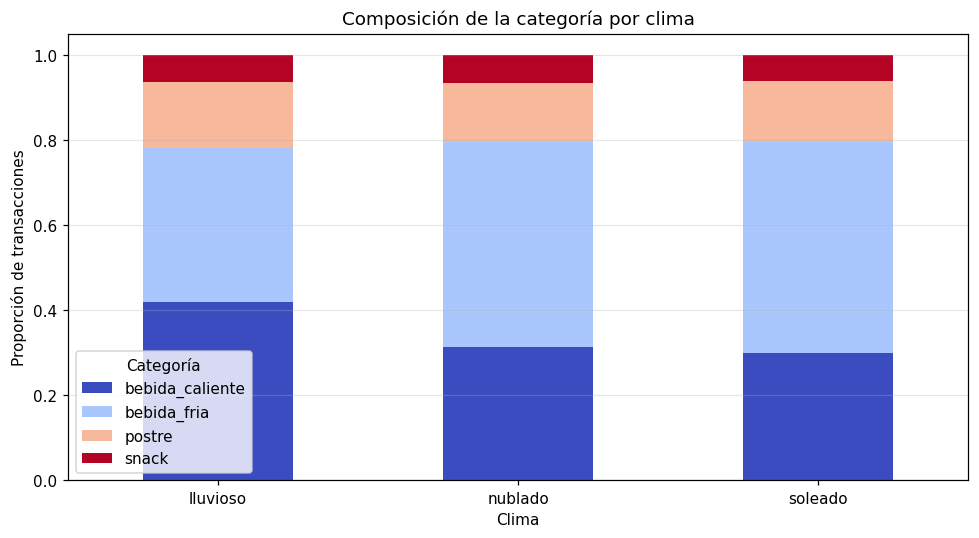

In [44]:
proporciones = tabla.div(tabla.sum(axis=1), axis=0)
ax = proporciones.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="coolwarm")
ax.set_title("Composición de la categoría por clima")
ax.set_ylabel("Proporción de transacciones")
ax.set_xlabel("Clima")
ax.legend(title="Categoría")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9.3 Chi-cuadrado e intensidad de la relación

El **chi-cuadrado de independencia** indica si la asociación es estadísticamente significativa. **Cramér's V** mide la fuerza de la asociación (0 = independencia, 1 = dependencia perfecta).

In [45]:
chi2, p, dof, _ = stats.chi2_contingency(tabla)
n = tabla.values.sum()
cramers_v = np.sqrt((chi2 / n) / (min(tabla.shape) - 1))
print(f"Chi-cuadrado = {chi2:.2f}  ·  g.l. = {dof}  ·  p = {p:.3e}")
print(f"Cramér's V = {cramers_v:.4f}")
print("Interpretación: V < 0.10 es una asociación débil.")

Chi-cuadrado = 183.40  ·  g.l. = 6  ·  p = 6.417e-37
Cramér's V = 0.0875
Interpretación: V < 0.10 es una asociación débil.


## 9.4 Lo que le importa a la gerencia

¿La bebida caliente se vende proporcionalmente más en días lluviosos? ¿Y el volumen (unidades) cambia con el clima?

In [46]:
share_caliente = df.groupby("clima")["categoria"].apply(
    lambda s: (s == "bebida_caliente").mean()
)
print("Proporción de bebida caliente por clima:")
print(share_caliente.round(3).to_string())

print("\nUnidades promedio por clima:")
print(df.groupby("clima")["unidades"].mean().round(3).to_string())

Proporción de bebida caliente por clima:
clima
lluvioso    0.419
nublado     0.313
soleado     0.299

Unidades promedio por clima:
clima
lluvioso    1.456
nublado     1.423
soleado     1.420


## 9.5 Correlación ≠ causalidad: variables confusoras

Los datos muestran una **asociación** real y significativa entre clima y categoría. Pero eso **no** prueba que el clima *cause* las ventas. Variables ocultas (confusoras) pueden explicar la misma relación:

- **Hora del día:** el mix de bebida caliente/fría depende del momento del día. Si los días lluviosos concentran compras en la mañana, la "causa" aparente no es el clima sino la hora.
- **Promociones:** si las promociones coinciden con días lluviosos, el aumento de ventas vendría de la promoción, no del clima.
- **Sucursal y hábitos de zona:** cada sucursal tiene su mix de clientes.
- La **música** del ejemplo de clase: si en días lluviosos se pone otro playlist, la música *correlaciona* con las ventas sin causarlas — es una correlación espuria.

Comprobamos el confusor de la hora en los propios datos:

In [47]:
share_hora = df.groupby("hora")["categoria"].apply(
    lambda s: (s == "bebida_caliente").mean()
)
print("Proporción de bebida caliente por hora:")
print(share_hora.round(3).to_string())

manana = df[df["hora"] <= 10]
tarde = df[df["hora"] >= 11]
print(f"\nMañana (hora ≤ 10): {(manana['categoria'] == 'bebida_caliente').mean():.3f}")
print(f"Tarde  (hora ≥ 11): {(tarde['categoria'] == 'bebida_caliente').mean():.3f}")

Proporción de bebida caliente por hora:
hora
6     0.318
7     0.335
8     0.332
9     0.326
10    0.337
11    0.311
12    0.333
13    0.332
14    0.374
15    0.376
16    0.332
17    0.343
18    0.345
19    0.357

Mañana (hora ≤ 10): 0.330
Tarde  (hora ≥ 11): 0.342


## 9.6 Conclusión (lenguaje de negocio)

Los datos muestran una asociación **significativa pero débil** entre clima y categoría: en días lluviosos la bebida caliente pasa de ~30 % a ~42 % de las transacciones (chi-cuadrado p < 0.001, Cramér's V ≈ 0.09). Sin embargo, **no podemos afirmar que el clima cause esas ventas**: la hora del día, las promociones y el perfil de cada sucursal son variables confusoras que pueden producir la misma relación sin causalidad directa. La recomendación es usar el clima como **señal de pronóstico** (planear stock de bebida caliente en días lluviosos) y no como **causa** para justificar decisiones de precio o inversión.

---

# Sello 10 — Regresión

### Un modelo que prediga las ventas futuras

**Pregunta de negocio del sello:** ¿qué variables predicen mejor las unidades vendidas?

**Modelo:** `unidades ~ precio_unitario + promocion_activa + clima + hora + sucursal + categoria`

In [48]:
d = df.copy()
d["monto"] = d["precio_unitario"] * d["unidades"]
d = pd.get_dummies(
    d, columns=["clima", "sucursal", "categoria", "medio_pago"],
    drop_first=True, dtype=int,
)
predictores = ["precio_unitario", "promocion_activa", "hora"] + [
    c for c in d.columns
    if c.startswith(("clima_", "sucursal_", "categoria_"))
]
print("Predictores del modelo:")
for p in predictores:
    print(" -", p)
print("\nVariable objetivo `unidades`:")
print(d["unidades"].value_counts().sort_index().to_string())

Predictores del modelo:
 - precio_unitario
 - promocion_activa
 - hora
 - clima_nublado
 - clima_soleado
 - sucursal_Escazu
 - sucursal_Heredia
 - sucursal_San Pedro
 - categoria_bebida_fria
 - categoria_postre
 - categoria_snack

Variable objetivo `unidades`:
unidades
1    8255
2    2470
3    1082
4     176


## 10.2 Ajuste del modelo (OLS)

Ajustamos el modelo con `statsmodels`. La categoría de referencia de cada variable categórica queda omitida (clima base = `lluvioso`, sucursal base = `Cartago`, categoría base = `bebida_caliente`).

In [49]:
import statsmodels.api as sm

X = sm.add_constant(d[predictores].astype(float))
modelo = sm.OLS(d["unidades"].astype(float), X).fit()
print(modelo.summary().tables[1].as_text())
print(f"R² = {modelo.rsquared:.4f}  ·  R² ajustado = {modelo.rsquared_adj:.4f}")

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.3561      0.041     33.211      0.000       1.276       1.436
precio_unitario       -2.321e-05   2.16e-05     -1.077      0.282   -6.55e-05     1.9e-05
promocion_activa          0.4960      0.013     37.486      0.000       0.470       0.522
hora                     -0.0009      0.001     -0.601      0.548      -0.004       0.002
clima_nublado            -0.0070      0.016     -0.438      0.662      -0.038       0.024
clima_soleado             0.0047      0.016      0.298      0.766      -0.026       0.036
sucursal_Escazu          -0.0378      0.018     -2.066      0.039      -0.074      -0.002
sucursal_Heredia         -0.0157      0.018     -0.894      0.372      -0.050       0.019
sucursal_San Pedro       -0.0137      0.018     -0.776      0.438      -0.048       0.021
categoria_

## 10.3 ¿Cuál predictor importa más?

Estandarizamos los predictores (media 0, desviación 1) para que los coeficientes sean comparables y poder ordenarlos por importancia.

In [50]:
Xz = (d[predictores] - d[predictores].mean()) / d[predictores].std()
modelo_z = sm.OLS(d["unidades"].astype(float), sm.add_constant(Xz)).fit()
importancia = modelo_z.params.drop("const").sort_values(key=abs, ascending=False)
print("Coeficientes estandarizados (importancia relativa):")
print(importancia.round(4).to_string())

Coeficientes estandarizados (importancia relativa):
promocion_activa         0.2332
categoria_postre        -0.0182
categoria_bebida_fria   -0.0171
sucursal_Escazu         -0.0164
precio_unitario         -0.0083
sucursal_Heredia        -0.0068
sucursal_San Pedro      -0.0059
hora                    -0.0037
clima_nublado           -0.0033
clima_soleado            0.0023
categoria_snack         -0.0013


## 10.4 Interpretación en lenguaje de negocio

Leemos los coeficientes del modelo original como efectos sobre las **unidades vendidas**.

In [51]:
def interp(nombre, coef, pv):
    sig = "significativo" if pv < 0.05 else "no significativo"
    dir_ = "aumenta" if coef > 0 else "reduce"
    print(f"{nombre}: β = {coef:.4f} (p = {pv:.4f}) → {dir_} las unidades · {sig}")

interp("precio_unitario (por 1 colón)", modelo.params["precio_unitario"],
       modelo.pvalues["precio_unitario"])
interp("promocion_activa (1 vs 0)", modelo.params["promocion_activa"],
       modelo.pvalues["promocion_activa"])
interp("hora", modelo.params["hora"], modelo.pvalues["hora"])
interp("clima_soleado (vs lluvioso)", modelo.params["clima_soleado"],
       modelo.pvalues["clima_soleado"])
interp("categoria_postre (vs bebida_caliente)", modelo.params["categoria_postre"],
       modelo.pvalues["categoria_postre"])
interp("sucursal_Escazu (vs Cartago)", modelo.params["sucursal_Escazu"],
       modelo.pvalues["sucursal_Escazu"])

precio_unitario (por 1 colón): β = -0.0000 (p = 0.2817) → reduce las unidades · no significativo
promocion_activa (1 vs 0): β = 0.4960 (p = 0.0000) → aumenta las unidades · significativo
hora: β = -0.0009 (p = 0.5480) → reduce las unidades · no significativo
clima_soleado (vs lluvioso): β = 0.0047 (p = 0.7658) → aumenta las unidades · no significativo
categoria_postre (vs bebida_caliente): β = -0.0517 (p = 0.0081) → reduce las unidades · significativo
sucursal_Escazu (vs Cartago): β = -0.0378 (p = 0.0388) → reduce las unidades · significativo


## 10.5 Validación en datos no vistos (sklearn)

Separamos 75 % entrenamiento / 25 % prueba para medir el poder predictivo real.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_ = d[predictores].to_numpy()
y_ = d["unidades"].to_numpy()
Xt, Xv, yt, yv = train_test_split(X_, y_, test_size=0.25, random_state=42)
lr = LinearRegression().fit(Xt, yt)
print(f"R² entrenamiento = {r2_score(yt, lr.predict(Xt)):.4f}")
print(f"R² validación    = {r2_score(yv, lr.predict(Xv)):.4f}")

R² entrenamiento = 0.1101
R² validación    = 0.1009


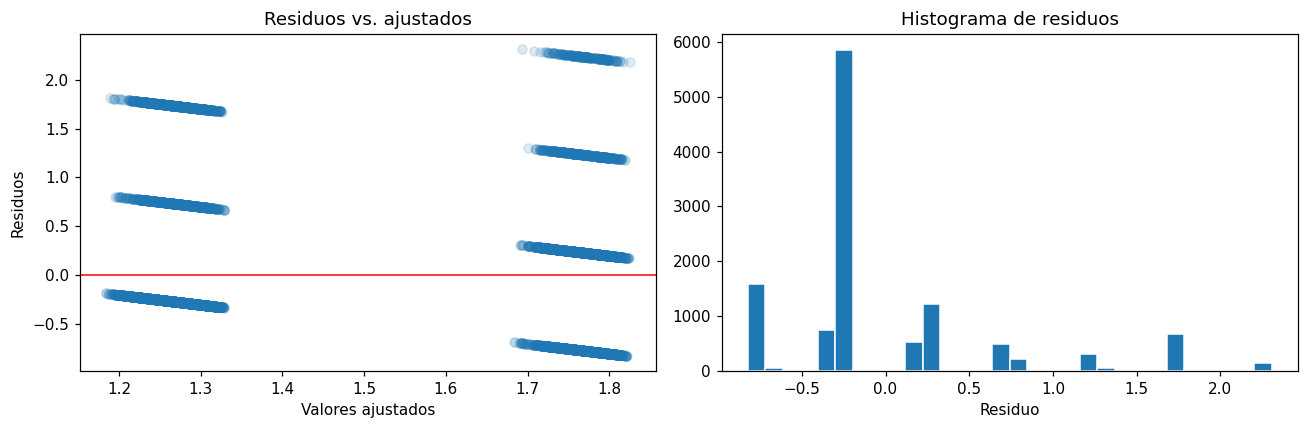

In [53]:
res = modelo.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(modelo.fittedvalues, res, alpha=0.15)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("Valores ajustados")
ax[0].set_ylabel("Residuos")
ax[0].set_title("Residuos vs. ajustados")
ax[1].hist(res, bins=30, edgecolor="white")
ax[1].set_xlabel("Residuo")
ax[1].set_title("Histograma de residuos")
plt.tight_layout()
plt.show()

## 10.6 Robustez: `unidades` es un conteo

La variable dependiente toma valores 1–4. Como chequeo, ajustamos una regresión **Poisson** (adecuada para conteos) y comparamos los coeficientes.

In [54]:
from statsmodels.discrete.count_model import Poisson

Xp = sm.add_constant(d[predictores].astype(float))
pois = Poisson(d["unidades"].astype(int), Xp).fit(disp=0)
print(f"Pseudo-R² (McFadden) = {pois.prsquared:.4f}")
print(pois.params.round(4).to_string())

Pseudo-R² (McFadden) = 0.0148
const                    0.2995
precio_unitario         -0.0000
promocion_activa         0.3302
hora                    -0.0006
clima_nublado           -0.0056
clima_soleado            0.0027
sucursal_Escazu         -0.0269
sucursal_Heredia        -0.0109
sucursal_San Pedro      -0.0094
categoria_bebida_fria   -0.0239
categoria_postre        -0.0362
categoria_snack         -0.0034


## 10.7 Conclusión (lenguaje de negocio)

El modelo explica cerca del **11 %** de la variabilidad de las unidades (R² ≈ 0.11, similar en validación), por lo que sirve como punto de partida, no como predicción exacta. **La promoción activa es el predictor más fuerte**: tener promoción activa añade ≈ **0.5 unidades** por transacción (p < 0.001). El precio y el clima tienen efectos despreciables y no significativos sobre la cantidad vendida; la hora tampoco pesa. La categoría y la sucursal aportan diferencias pequeñas (postre ≈ −0.05 unidades vs. bebida caliente; Escazú ≈ −0.04 vs. Cartago). **Recomendación de negocio:** si la meta es vender más unidades, la palanca efectiva es la promoción, no bajar precios ni responder al clima; para decisiones de pronóstico, incorporar variables como demanda histórica y día de la semana.

---

## Cierre — síntesis de los sellos

| Sello | Hallazgo principal | Implicación para la gerencia |
|---|---|---|
| 1 | Escazú es la sucursal con mayor facturación; bebida fría es la categoría estrella y el Frappe el producto estrella | Concentrar inventario y promoción en la línea fría sin descuidar el margen de las demás categorías |
| 2 | P(postre \| bebida caliente) es ligeramente menor que P(postre) marginal | Un combo bebida caliente + postre no se justifica solo por el comportamiento de compra observado |
| 3 | La probabilidad de recurrencia sube de ~43 % a ~60 % cuando la primera compra incluyó postre | El postre en la primera visita sirve como señal de fidelización, aunque no queda demostrada causalidad |
| 4 | Las llegadas por hora siguen una Poisson (índice de dispersión ≈ 1); los picos son 7–9 h y 16–18 h | Dimensionar turnos y preparación por franja horaria, no por promedio diario |
| 5 | 71 % de las calificaciones faltan, pero la no respuesta no depende de sucursal, clima, categoría ni monto | El sesgo de no respuesta no es detectable con las variables observables; aun así la media observada no debe leerse como la de todos los clientes |
| 6 | Ticket promedio con IC 95 % estrecho; solo Escazú se separa del resto | Usar el rango, no el punto, al proyectar ingresos |
| 7 | ANOVA rechaza la igualdad de sucursales; Escazú lidera, Heredia queda última | Replicar prácticas de Escazú donde el gap es mayor |
| 8 | La promoción sube las unidades de forma significativa, con efecto mediano-grande | Mantener las promociones, priorizando el 2x1 en bebidas |
| 9 | Clima y categoría están asociados, pero la asociación es débil y hay confusores | No atribuir causalidad al clima sin un diseño experimental |
| 10 | El modelo explica ~11 % de la varianza; la promoción es el predictor dominante | Usar el modelo como guía direccional, no como pronóstico exacto |